<a href="https://colab.research.google.com/github/sush123-mita/aiml/blob/main/NNImage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Summary

This project demonstrates a basic image classification task using a simple Artificial Neural Network (ANN) on the CIFAR-10 dataset. The key steps involved are:

1.  **Environment Setup**: TensorFlow and Keras libraries were imported, and the availability of GPU devices was checked.
2.  **Data Loading**: The CIFAR-10 dataset was loaded using `tf.keras.datasets.cifar10.load_data()`, splitting it into training and testing sets.
3.  **Data Exploration**: The shapes of the training data (`X_train`, `y_train`) were inspected, and an example image from the training set was displayed along with its corresponding class label.
4.  **Data Preprocessing**:
    *   Image pixel values were scaled from the range `[0, 255]` to `[0, 1]` by dividing by 255 (normalization).
    *   The categorical labels (`y_train`, `y_test`) were converted into a one-hot encoded format using `keras.utils.to_categorical` to prepare them for the neural network's output layer.
5.  **Model Building**: A sequential Keras model was constructed with the following layers:
    *   `Flatten` layer: To convert the 2D image data (32x32x3) into a 1D vector (3072 features).
    *   Two `Dense` (fully connected) hidden layers with ReLU activation (3000 and 1000 neurons respectively).
    *   An `Dense` output layer with 10 neurons (for 10 classes) and sigmoid activation.
6.  **Model Compilation**: The model was compiled using the Stochastic Gradient Descent (`SGD`) optimizer, `categorical_crossentropy` as the loss function (suitable for one-hot encoded labels), and `accuracy` as the metric.
7.  **Model Training**: The model was trained on the scaled training data (`x_train_scaled`, `y_train_categorical`) for 2 epochs.
8.  **Prediction and Evaluation**:
    *   Predictions were made on the scaled test data (`x_test_scaled`).
    *   The model's performance was evaluated using `model.evaluate()`, which provided loss and accuracy on the test set.
    *   A classification report and a confusion matrix were generated using `sklearn.metrics` to provide a detailed breakdown of precision, recall, f1-score, and how well the model classified each class.
    *   A prediction for a single test image was demonstrated.

In [43]:
pip install tensorflow

In [44]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [45]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [46]:
print(tf.__version__)

2.20.0


In [47]:
tf.test.is_built_with_cuda()

True

In [48]:
(X_train, y_train), ( X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [49]:
X_train.shape

(50000, 32, 32, 3)

In [50]:
y_train.shape

(50000, 1)

[9]


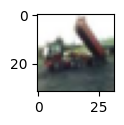

In [51]:
plt.figure(figsize=(10,1))#it shows canvas size on which the image will be drawn , with widht and height
plt.imshow(X_train[2])
print(y_train[2])

In [52]:
classes=["airplane","automobile", "bird","cat","deer","dog","frog","horse","ship","truck"]
classes[y_train[0][0]]

'frog'

In [53]:
#convert the values in the range 0,255 to 0.1- normalization for easy learning
x_train_scaled=X_train/255
x_test_scaled=X_test/255

In [54]:
y_train_categorical = keras.utils.to_categorical(y_train, num_classes=10)
y_train_categorical = y_train_categorical.astype('float32')

In [55]:
y_train_categorical[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [56]:
y_test_categorical=keras.utils.to_categorical(y_test,num_classes=10)
y_test_categorical=y_test_categorical.astype('float32')

In [57]:
#1.flatten the training set, 2.Set the output layer, 3. set the hidden layers
model=keras.Sequential([#Sequential means:"I want my layers to be arranged one after another."
     # Input image shape: 32x32 pixels with 3 RGB channels
    # Flatten converts 32x32x3 = 3072 values into a 1D vector
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000,activation= 'relu'),## Hidden layer: 3000 neurons
    # Number of neurons is a hyperparameter chosen/tuned experimentally
    # ReLU is commonly used in hidden layers because it trains efficiently
    keras.layers.Dense(1000,activation='relu'),# Hidden layer: 1000 neurons
    # Again, neuron count is a design/hyperparameter choice
    # ReLU is used as the hidden-layer activation
    keras.layers.Dense(10,activation='sigmoid')#Sigmoid is particularly useful when you want an output representing a binary probability.
])
model.compile(optimizer='SGD',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#if y_train is one hot encoded values , then loss used is categorical _crossentrpy
#if it is  discrete values, then use the sparse categorical crossentropy

model.fit(x_train_scaled,y_train_categorical,epochs=2)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3564 - loss: 1.8097
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4268 - loss: 1.6214


In [58]:
classes[np.argmax(model.predict(x_test_scaled)[6])]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


'cat'

Raw images
   ↓
Scale pixel values
   ↓
Flatten each image
   ↓
Hidden layer
   ↓
Hidden layer
   ↓
Output layer
   ↓
Calculate error (loss)
   ↓
Update weights (SGD)
   ↓
Repeat for 2 epochs

In [59]:
classes[y_test[6][0]]

'automobile'

In [60]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3000)           │     9,219,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1000)           │     3,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,230,012 (46.65 MB)

 Trainable params: 12,230,010 (46.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [61]:
model.evaluate(x_test_scaled,y_test_categorical)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4450 - loss: 1.5722


[1.5721899271011353, 0.4449999928474426]

In [62]:
model.predict(np.expand_dims(x_test_scaled[1], axis=0))
#"Take the second test image, add a batch dimension to it, and ask the trained model to predict its class."

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


array([[0.7857783 , 0.9583147 , 0.23688757, 0.31443056, 0.12274817,
        0.15024866, 0.03422659, 0.07892793, 0.9513407 , 0.95276016]],
      dtype=float32)

In [63]:
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
y_pred=model.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [64]:
y_pred_class = [np.argmax(y) for y in y_pred] #This converts those probabilities into a class number.
#np.argmax(y) finds the position of the largest value.
print(classification_report(y_test, y_pred_class))#compares the actual labels with predicted labels
print(confusion_matrix(y_test, y_pred_class))#Which classes your model is confusing with which other classes.

              precision    recall  f1-score   support

           0       0.52      0.50      0.51      1000
           1       0.52      0.62      0.56      1000
           2       0.35      0.29      0.32      1000
           3       0.32      0.35      0.33      1000
           4       0.45      0.25      0.32      1000
           5       0.31      0.43      0.36      1000
           6       0.44      0.59      0.50      1000
           7       0.64      0.31      0.41      1000
           8       0.54      0.64      0.58      1000
           9       0.51      0.47      0.49      1000

    accuracy                           0.45     10000
   macro avg       0.46      0.45      0.44     10000
weighted avg       0.46      0.45      0.44     10000

[[503  56  58  35  12  44  29  20 200  43]
 [ 38 616  12  43  10  50  29  14  71 117]
 [107  31 292 122  73 128 151  27  49  20]
 [ 31  41  60 354  16 261 126  18  33  60]
 [ 71  28 177  73 251 136 171  38  36  19]
 [ 25  30  82 205  36 431 